# Flight Delay Prediction — Logistic Regression

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score,
    precision_recall_curve, RocCurveDisplay, average_precision_score
)
from imblearn.over_sampling import SMOTE
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5
np.random.seed(RANDOM_STATE)
print("Libraries loaded")

Libraries loaded ✅


## 2. Load Data

In [2]:
train = pd.read_csv("flight_dataset_v1.csv", parse_dates=[
    "scheduled_departure_time", "actual_departure_time",
    "scheduled_arrival_time", "actual_arrival_time", "dep_date_only"
])
print(f"Shape: {train.shape}")
print(train.head())

Shape: (9754, 54)
  id             airline origin_code destination_code    route aircraft_type  \
0  1  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
1  2  SriLankan Airlines         CMB              BOM  CMB_BOM          A332   
2  3  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
3  4  SriLankan Airlines         CMB              BOM  CMB_BOM          A20N   
4  5  SriLankan Airlines         CMB              BOM  CMB_BOM          A320   

  scheduled_departure_time actual_departure_time scheduled_arrival_time  \
0      2025-12-01 23:40:00        12/2/2025 1:44    2025-12-02 02:10:00   
1      2025-11-30 23:40:00        12/1/2025 2:04    2025-12-01 02:10:00   
2      2025-11-30 08:28:00       11/30/2025 8:28    2025-11-30 10:28:00   
3      2025-11-29 23:40:00                     0    2025-11-30 02:10:00   
4      2025-11-28 23:40:00                     0    2025-11-29 02:10:00   

  actual_arrival_time  departure_delay_min  arriva

## 3. Remove Cancelled & Diverted

In [3]:
print(f"Cancelled : {train['is_cancelled'].sum()} rows")
print(f"Diverted  : {train['is_diverted'].sum()} rows")

df = train[
    (train['is_cancelled'] == 0) &
    (train['is_diverted']  == 0)
].copy().reset_index(drop=True)

df['departure_delay_min'] = df['departure_delay_min'].clip(lower=0)
print(f"Clean shape: {df.shape}")

Cancelled : 52 rows
Diverted  : 10 rows
Clean shape: (9692, 54)


## 4. Feature Engineering

In [ ]:
# ── Targets ───────────────────────────────────────────────────────────────────
df['target_binary']   = (df['departure_delay_min'] >= 15).astype(int)
df['target_severity'] = (df['departure_delay_min'] >= 60).astype(int)

print(f"Binary   — On-Time: {(df['target_binary']==0).sum():,} | Delayed: {(df['target_binary']==1).sum():,}")
delayed_df = df[df['target_binary']==1]
print(f"Severity — Minor  : {(delayed_df['target_severity']==0).sum():,} | Major: {(delayed_df['target_severity']==1).sum():,}")

# ── Cyclical time features ─────────────────────────────────────────────────────
for col, prefix in [('scheduled_departure_hour','dep'),('scheduled_arrival_hour','arr')]:
    if col in df.columns:
        df[f'{prefix}_hour_sin'] = np.sin(2 * np.pi * df[col] / 24)
        df[f'{prefix}_hour_cos'] = np.cos(2 * np.pi * df[col] / 24)

# ── Day of week: string → int → cyclical ──────────────────────────────────────
day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
           'Friday':4,'Saturday':5,'Sunday':6}
for col in ['scheduled_departure_day_of_week','scheduled_arrival_day_of_week']:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].map(day_map)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / 7)
        df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / 7)

# ── Interaction features ───────────────────────────────────────────────────────
if all(c in df.columns for c in ['dep_precipitation','arr_precipitation']):
    df['total_precipitation'] = df['dep_precipitation'] + df['arr_precipitation']
    df['any_precipitation']   = ((df['dep_precipitation']>0)|(df['arr_precipitation']>0)).astype(int)

if all(c in df.columns for c in ['scheduled_late_night_departure','dep_is_monsoon_season']):
    df['night_monsoon'] = df['scheduled_late_night_departure'] * df['dep_is_monsoon_season']

if all(c in df.columns for c in ['airline_delay_rate','route_delay_rate']):
    df['airline_route_risk'] = df['airline_delay_rate'] * df['route_delay_rate']

if all(c in df.columns for c in ['route_avg_delay','scheduled_is_peak_hour']):
    df['route_delay_peak'] = df['route_avg_delay'] * df['scheduled_is_peak_hour']

print("Feature engineering complete ")

Binary   — On-Time: 6,457 | Delayed: 3,235
Severity — Minor  : 2,794 | Major: 441
Feature engineering complete ✅


## 5. Drop Leakage & Encode

In [5]:
DROP_COLS = [
    'id', 'dep_date_only',
    'actual_departure_time', 'actual_arrival_time',
    'scheduled_departure_time', 'scheduled_arrival_time',
    'departure_delay_min', 'arrival_delay_min', 'delay_ratio',
    'binary_delay_dep', 'binary_delay_arr',
    'delay_class_dep', 'delay_class_arr',
    'is_diverted', 'is_cancelled',
    'origin_code',
    'dep_wind_speed_100m', 'arr_wind_speed_100m',
    'target_binary', 'target_severity',
]

CAT_FEATURES = ['airline', 'aircraft_type', 'destination_code', 'route']

feature_cols = [c for c in df.columns if c not in DROP_COLS]
dt_cols = df[feature_cols].select_dtypes(include=['datetime64','object']).columns.tolist()

# Label encode categoricals (required for RF, XGB, LR — unlike CatBoost)
le_dict = {}
for col in CAT_FEATURES:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

feature_cols = [c for c in feature_cols if c not in dt_cols]
X_all      = df[feature_cols].copy()
y_binary   = df['target_binary'].copy()
y_severity = df['target_severity'].copy()

print(f"Feature matrix : {X_all.shape}")
print(f"Binary target  : {dict(y_binary.value_counts().sort_index())}")

Feature matrix : (9692, 45)
Binary target  : {0: np.int64(6457), 1: np.int64(3235)}


## 6. Model 1 — Binary Classifier
### 6a. Split

In [6]:
X1_train, X1_valid, y1_train, y1_valid = train_test_split(
    X_all, y_binary,
    test_size=TEST_SIZE, stratify=y_binary, random_state=RANDOM_STATE
)
print(f"Train: {X1_train.shape} | Valid: {X1_valid.shape}")
print(f"Class dist: {dict(y1_train.value_counts().sort_index())}")

Train: (7753, 45) | Valid: (1939, 45)
Class dist: {0: np.int64(5165), 1: np.int64(2588)}


### 6b. SMOTE

In [7]:
sm1 = SMOTE(random_state=RANDOM_STATE)
X1_train_res, y1_train_res = sm1.fit_resample(X1_train, y1_train)
print(f"Before SMOTE: {dict(y1_train.value_counts().sort_index())}")
print(f"After  SMOTE: {dict(pd.Series(y1_train_res).value_counts().sort_index())}")

Before SMOTE: {0: np.int64(5165), 1: np.int64(2588)}
After  SMOTE: {0: np.int64(5165), 1: np.int64(5165)}


### 6c. Scale Features
Logistic Regression is sensitive to feature scale — StandardScaler is mandatory.
Tree-based models (RF, XGB, LightGBM, CatBoost) do NOT need this.


In [ ]:
scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train_res)  # fit on train only
X1_valid_scaled = scaler.transform(X1_valid)           # transform valid with same scaler
print("Features scaled (fitted on training set only)")

Features scaled ✅ (fitted on training set only)


### 6d. Hyperparameter Search (C + solver + penalty)

In [9]:
from sklearn.model_selection import GridSearchCV

# C = inverse regularization strength (smaller = more regularization)
param_grid = {
    'C':       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver':  ['saga'],       # saga supports all penalties
    'l1_ratio':[0.0, 0.5, 1.0],  # only used with elasticnet
    'max_iter':[2000],
}

base_lr = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    base_lr, param_grid,
    scoring='roc_auc', cv=cv,
    n_jobs=-1, verbose=1
)
grid_search.fit(X1_train_scaled, y1_train_res)

print(f"\nBest CV ROC AUC : {grid_search.best_score_:.4f}")
print("Best params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best CV ROC AUC : 0.7966
Best params:
  C: 0.1
  l1_ratio: 0.0
  max_iter: 2000
  penalty: l2
  solver: saga


### 6e. Train Final Model 1

In [10]:
MODEL_NAME = "Logistic Regression"

model1 = LogisticRegression(
    **grid_search.best_params_,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
model1.fit(X1_train_scaled, y1_train_res)

y1_proba = model1.predict_proba(X1_valid_scaled)[:, 1]
print(f"Validation ROC AUC : {roc_auc_score(y1_valid, y1_proba):.4f}")

Validation ROC AUC : 0.6819


### 6f. Threshold Tuning

Default (0.50) → F1: 0.4966
Tuned  (0.3583) → F1: 0.5547


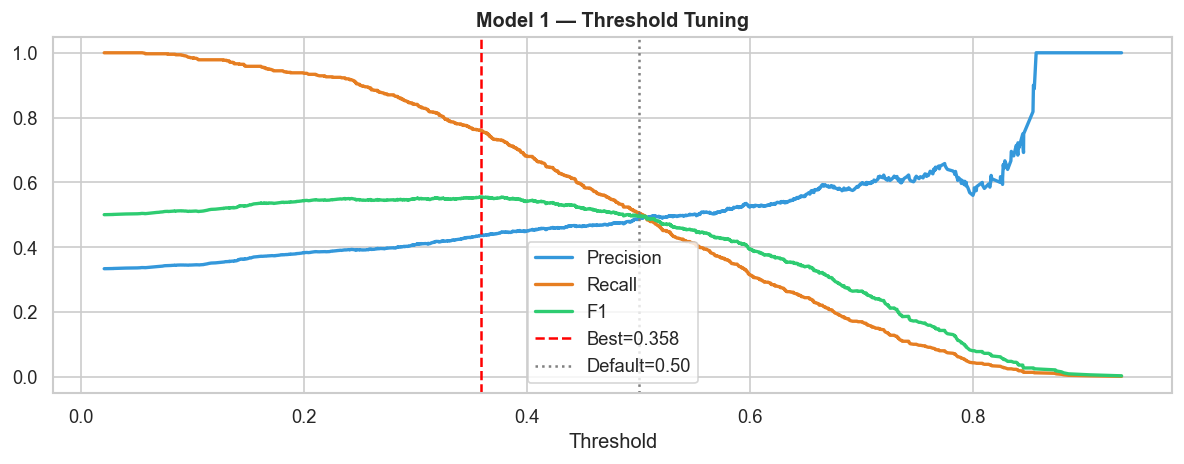

In [11]:
precisions, recalls, thresholds = precision_recall_curve(y1_valid, y1_proba)
f1s        = 2*(precisions[:-1]*recalls[:-1]) / (precisions[:-1]+recalls[:-1]+1e-8)
best_idx   = np.argmax(f1s)
threshold1 = thresholds[best_idx]

print(f"Default (0.50) → F1: {f1_score(y1_valid,(y1_proba>=0.50).astype(int)):.4f}")
print(f"Tuned  ({threshold1:.4f}) → F1: {f1s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', lw=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#e67e22', lw=2)
ax.plot(thresholds, f1s,             label='F1',        color='#2ecc71', lw=2)
ax.axvline(threshold1, color='red',  linestyle='--', lw=1.5, label=f'Best={threshold1:.3f}')
ax.axvline(0.50,       color='gray', linestyle=':',  lw=1.5, label='Default=0.50')
ax.set_xlabel('Threshold'); ax.set_title('Model 1 — Threshold Tuning', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

y1_pred_tuned = (y1_proba >= threshold1).astype(int)

### 6g. Evaluation

In [12]:
print("="*55)
print("  MODEL 1 — BINARY (Logistic Regression)")
print("="*55)
print(f"  Accuracy    : {accuracy_score(y1_valid, y1_pred_tuned):.4f}")
print(f"  ROC AUC     : {roc_auc_score(y1_valid, y1_proba):.4f}")
print(f"  F1 Macro    : {f1_score(y1_valid, y1_pred_tuned, average='macro'):.4f}")
print(f"  F1 Weighted : {f1_score(y1_valid, y1_pred_tuned, average='weighted'):.4f}")
print(f"  Precision   : {precision_score(y1_valid, y1_pred_tuned, zero_division=0):.4f}")
print(f"  Recall      : {recall_score(y1_valid, y1_pred_tuned, zero_division=0):.4f}")
print(classification_report(y1_valid, y1_pred_tuned, target_names=['On-Time','Delayed']))

  MODEL 1 — BINARY (Logistic Regression)
  Accuracy    : 0.5926
  ROC AUC     : 0.6819
  F1 Macro    : 0.5896
  F1 Weighted : 0.6012
  Precision   : 0.4366
  Recall      : 0.7604
              precision    recall  f1-score   support

     On-Time       0.81      0.51      0.62      1292
     Delayed       0.44      0.76      0.55       647

    accuracy                           0.59      1939
   macro avg       0.62      0.63      0.59      1939
weighted avg       0.68      0.59      0.60      1939



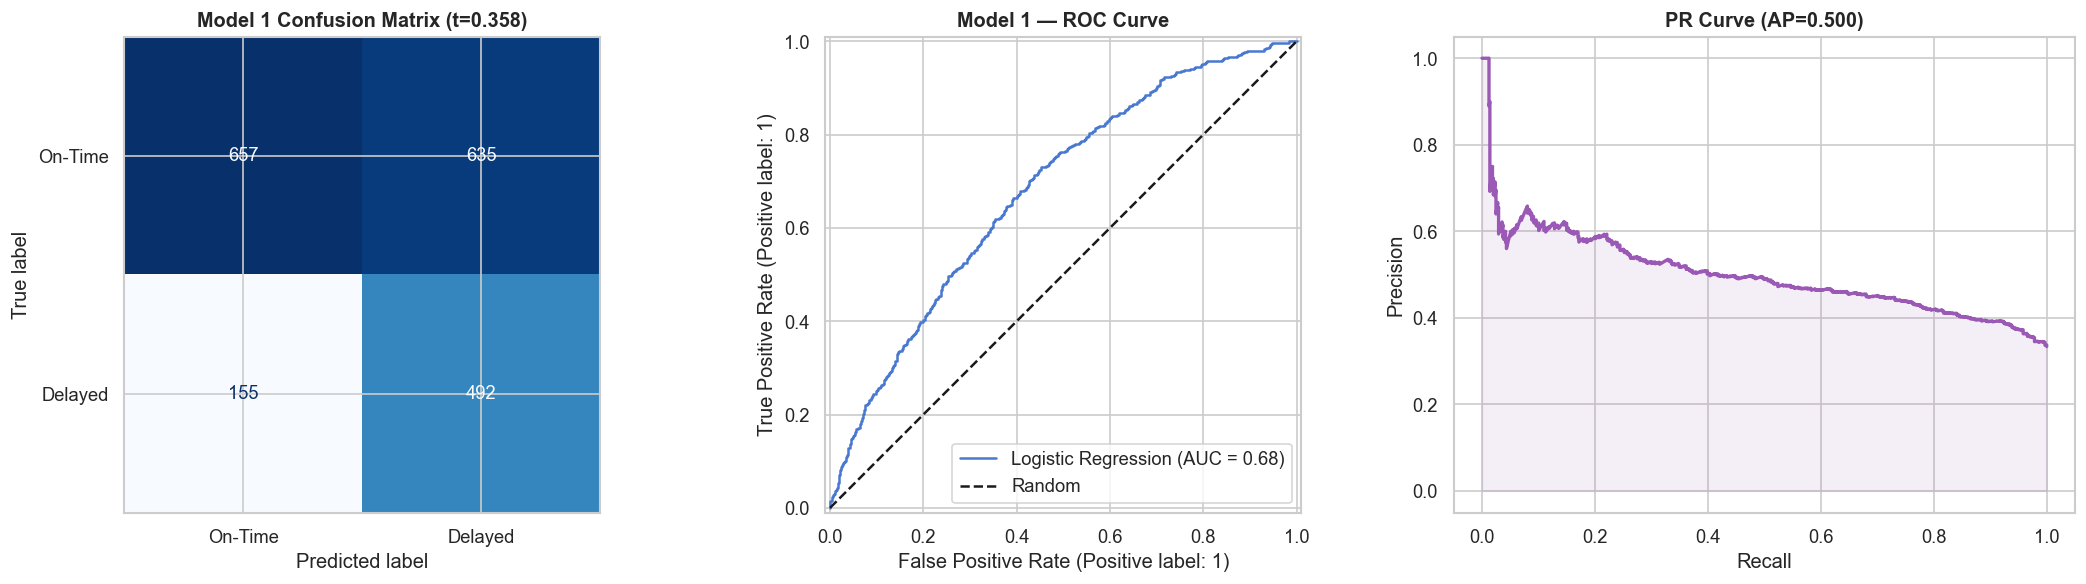

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm1 = confusion_matrix(y1_valid, y1_pred_tuned)
ConfusionMatrixDisplay(cm1, display_labels=['On-Time','Delayed']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Model 1 Confusion Matrix (t={threshold1:.3f})', fontweight='bold')

RocCurveDisplay.from_predictions(y1_valid, y1_proba, ax=axes[1], name=MODEL_NAME)
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title('Model 1 — ROC Curve', fontweight='bold')
axes[1].legend()

ap1 = average_precision_score(y1_valid, y1_proba)
precisions_pr, recalls_pr, _ = precision_recall_curve(y1_valid, y1_proba)
axes[2].plot(recalls_pr, precisions_pr, color='#9b59b6', lw=2)
axes[2].fill_between(recalls_pr, precisions_pr, alpha=0.1, color='#9b59b6')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title(f'PR Curve (AP={ap1:.3f})', fontweight='bold')

plt.tight_layout(); plt.show()

### 6h. Coefficient Analysis (Logistic Regression Interpretability)

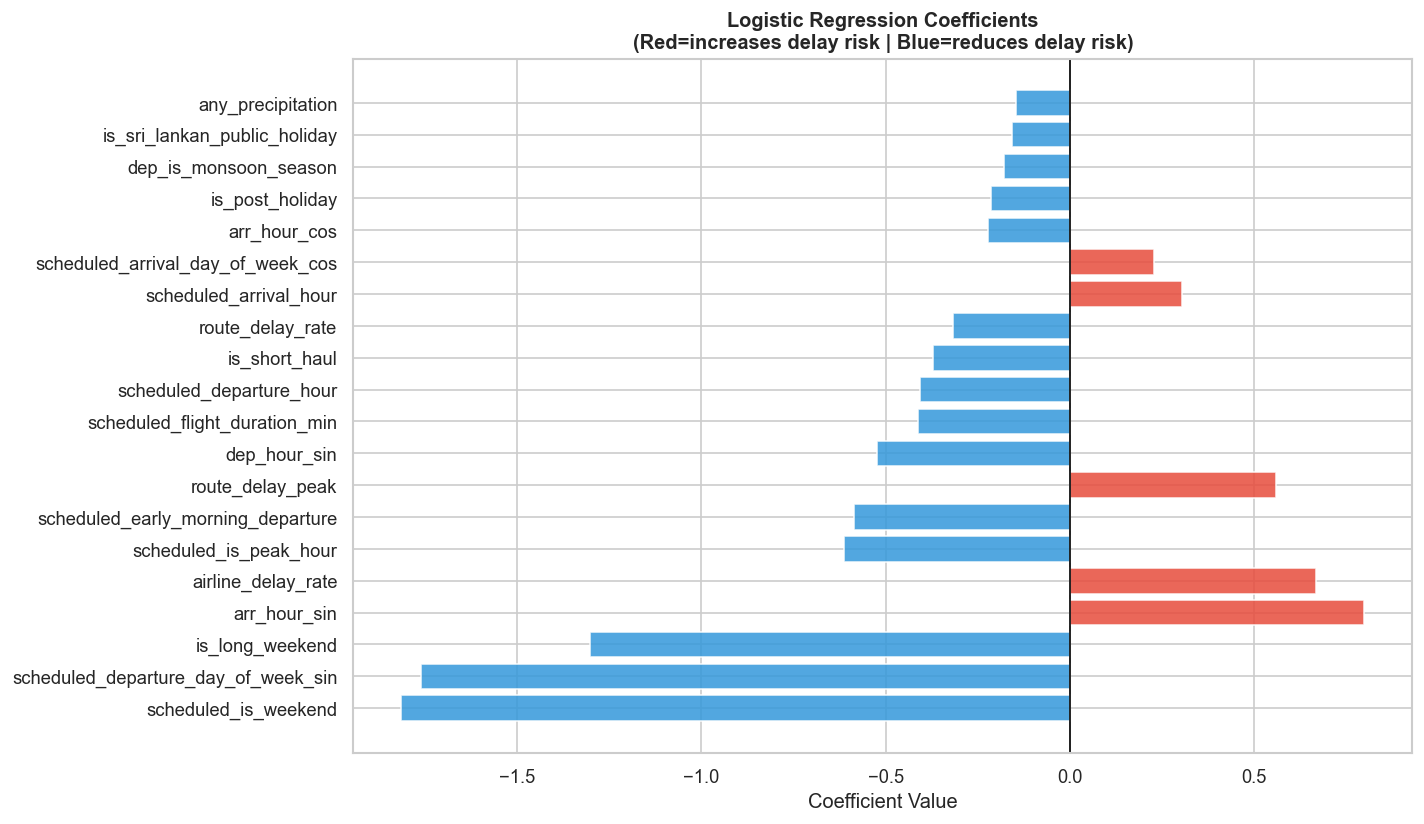


Top 10 features increasing delay probability (positive coef):
                          feature  coefficient
                     arr_hour_sin     0.798042
               airline_delay_rate     0.667185
                 route_delay_peak     0.559484
           scheduled_arrival_hour     0.302526
scheduled_arrival_day_of_week_cos     0.227819

Top 10 features reducing delay probability (negative coef):
                            feature  coefficient
               scheduled_is_weekend    -1.813670
scheduled_departure_day_of_week_sin    -1.760280
                    is_long_weekend    -1.302667
             scheduled_is_peak_hour    -0.613291
  scheduled_early_morning_departure    -0.585303
                       dep_hour_sin    -0.524196
      scheduled_flight_duration_min    -0.412097
           scheduled_departure_hour    -0.408323
                      is_short_haul    -0.372595
                   route_delay_rate    -0.318752


In [14]:
# Logistic Regression coefficients show direction of effect — unique advantage over tree models
coef_df = pd.DataFrame({
    'feature':     X1_train.columns,
    'coefficient': model1.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12,7))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients\n(Red=increases delay risk | Blue=reduces delay risk)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.show()

print("\nTop 10 features increasing delay probability (positive coef):")
print(coef_df[coef_df['coefficient']>0].head(10)[['feature','coefficient']].to_string(index=False))
print("\nTop 10 features reducing delay probability (negative coef):")
print(coef_df[coef_df['coefficient']<0].head(10)[['feature','coefficient']].to_string(index=False))

## 7. Model 2 — Severity Classifier

In [15]:
delayed_mask = y_binary == 1
X_delayed    = X_all[delayed_mask].copy().reset_index(drop=True)
y_sev        = y_severity[delayed_mask].copy().reset_index(drop=True)

print(f"Delayed subset : {X_delayed.shape[0]} rows")
print(f"Minor (0)      : {(y_sev==0).sum()} | Major (1): {(y_sev==1).sum()}")

X2_train, X2_valid, y2_train, y2_valid = train_test_split(
    X_delayed, y_sev,
    test_size=TEST_SIZE, stratify=y_sev, random_state=RANDOM_STATE
)

k = max(1, min(3, (y2_train==1).sum()-1))
sm2 = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
X2_train_res, y2_train_res = sm2.fit_resample(X2_train, y2_train)
print(f"After SMOTE: {dict(pd.Series(y2_train_res).value_counts().sort_index())}")

Delayed subset : 3235 rows
Minor (0)      : 2794 | Major (1): 441
After SMOTE: {0: np.int64(2235), 1: np.int64(2235)}


In [16]:
# Scale for model 2 (separate scaler — different distribution in delayed subset)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train_res)
X2_valid_scaled = scaler2.transform(X2_valid)

grid_search2 = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, verbose=0
)
grid_search2.fit(X2_train_scaled, y2_train_res)
print(f"Best CV AUC (M2): {grid_search2.best_score_:.4f}")

model2 = LogisticRegression(**grid_search2.best_params_,
                             class_weight='balanced', random_state=RANDOM_STATE)
model2.fit(X2_train_scaled, y2_train_res)
y2_proba = model2.predict_proba(X2_valid_scaled)[:, 1]
print(f"Validation AUC: {roc_auc_score(y2_valid, y2_proba):.4f}")

Best CV AUC (M2): 0.8718
Validation AUC: 0.4875


In [17]:
precisions2, recalls2, thresholds2 = precision_recall_curve(y2_valid, y2_proba)
f1s2       = 2*(precisions2[:-1]*recalls2[:-1]) / (precisions2[:-1]+recalls2[:-1]+1e-8)
best_idx2  = np.argmax(f1s2)
threshold2 = thresholds2[best_idx2]

print(f"Default (0.50) → F1: {f1_score(y2_valid,(y2_proba>=0.50).astype(int)):.4f}")
print(f"Tuned  ({threshold2:.4f}) → F1: {f1s2[best_idx2]:.4f}")
y2_pred_tuned = (y2_proba >= threshold2).astype(int)

Default (0.50) → F1: 0.1084
Tuned  (0.1722) → F1: 0.2462


  MODEL 2 — SEVERITY (Logistic Regression)
  Accuracy  : 0.3941
  ROC AUC   : 0.4875
  F1 Macro  : 0.3698
              precision    recall  f1-score   support

       Minor       0.89      0.34      0.49       559
       Major       0.15      0.73      0.25        88

    accuracy                           0.39       647
   macro avg       0.52      0.53      0.37       647
weighted avg       0.79      0.39      0.46       647



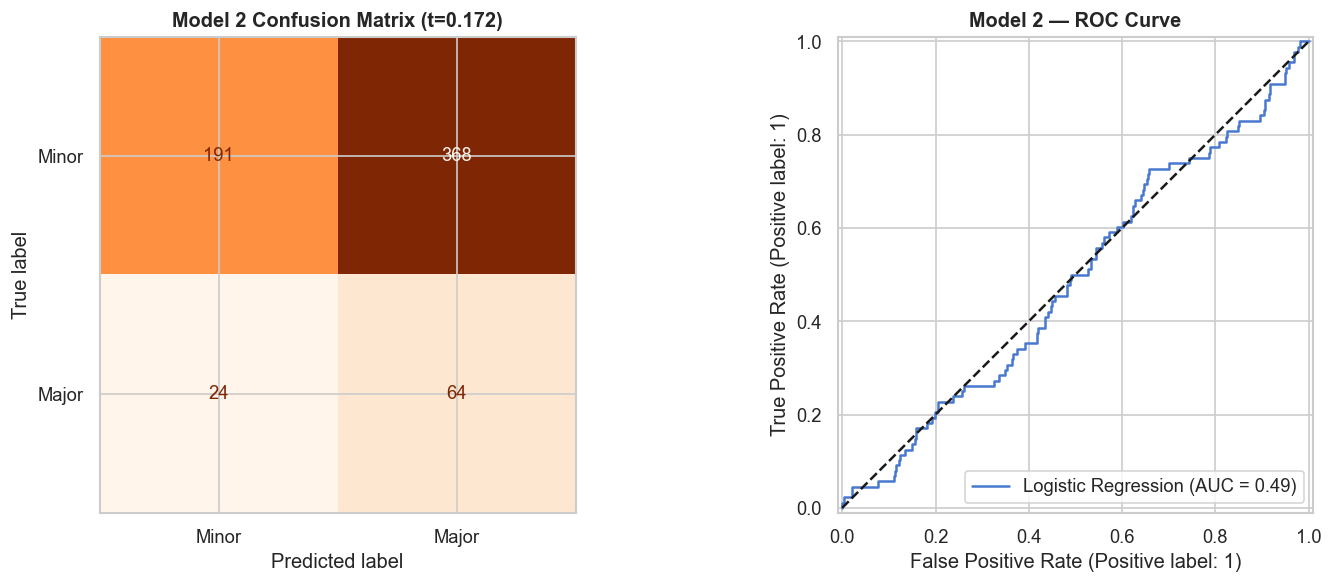

In [18]:
print("="*55)
print(f"  MODEL 2 — SEVERITY ({MODEL_NAME})")
print("="*55)
print(f"  Accuracy  : {accuracy_score(y2_valid, y2_pred_tuned):.4f}")
print(f"  ROC AUC   : {roc_auc_score(y2_valid, y2_proba):.4f}")
print(f"  F1 Macro  : {f1_score(y2_valid, y2_pred_tuned, average='macro'):.4f}")
print(classification_report(y2_valid, y2_pred_tuned, target_names=['Minor','Major']))

fig, axes = plt.subplots(1,2,figsize=(13,5))
cm2 = confusion_matrix(y2_valid, y2_pred_tuned)
ConfusionMatrixDisplay(cm2, display_labels=['Minor','Major']).plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title(f'Model 2 Confusion Matrix (t={threshold2:.3f})', fontweight='bold')
RocCurveDisplay.from_predictions(y2_valid, y2_proba, ax=axes[1], name=MODEL_NAME)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Model 2 — ROC Curve', fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Cascaded Prediction

  CASCADED SYSTEM — END-TO-END (Logistic Regression)
  Accuracy (3-class) : 0.4193
  F1 Macro           : 0.3292
  F1 Weighted        : 0.4912
              precision    recall  f1-score   support

     On-Time       0.81      0.51      0.62      1292
       Minor       0.39      0.17      0.24       558
       Major       0.07      0.66      0.12        89

    accuracy                           0.42      1939
   macro avg       0.42      0.45      0.33      1939
weighted avg       0.66      0.42      0.49      1939



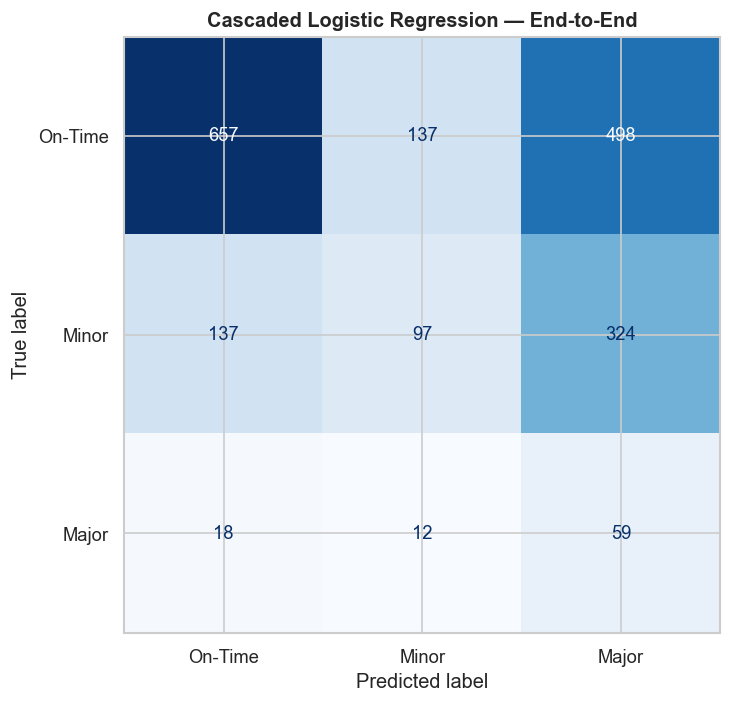

In [19]:
# LR cascaded — must scale inputs
def cascaded_predict_lr(X_new, model_b, model_s, scaler_b, scaler_s, thresh_b, thresh_s):
    X_scaled_b = scaler_b.transform(X_new)
    prob_del    = model_b.predict_proba(X_scaled_b)[:, 1]
    is_del      = (prob_del >= thresh_b).astype(int)
    sev_prob    = np.zeros(len(X_new))
    del_idx     = np.where(is_del==1)[0]
    if len(del_idx) > 0:
        X_scaled_s = scaler_s.transform(X_new.iloc[del_idx])
        sev_prob[del_idx] = model_s.predict_proba(X_scaled_s)[:, 1]
    is_major   = (sev_prob >= thresh_s).astype(int)
    final_pred = np.where(is_del==0, 0, np.where(is_major==0, 1, 2))
    label_map  = {0:'On-Time (<15 min)', 1:'Minor (15–59 min)', 2:'Major (≥60 min)'}
    confidence = np.where(is_del==0, 1-prob_del,
                 np.where(is_major==1, sev_prob, 1-sev_prob))
    return pd.DataFrame({
        'delay_predicted': final_pred,
        'delay_label':     [label_map[p] for p in final_pred],
        'binary_prob':     prob_del.round(4),
        'severity_prob':   sev_prob.round(4),
        'confidence':      confidence.round(4)
    })

y_true_3class = np.where(
    y_binary[X1_valid.index]==0, 0,
    np.where(y_severity[X1_valid.index]==0, 1, 2)
)
results = cascaded_predict_lr(X1_valid, model1, model2, scaler, scaler2, threshold1, threshold2)

print("="*55)
print("  CASCADED SYSTEM — END-TO-END (Logistic Regression)")
print("="*55)
print(f"  Accuracy (3-class) : {accuracy_score(y_true_3class, results['delay_predicted']):.4f}")
print(f"  F1 Macro           : {f1_score(y_true_3class, results['delay_predicted'], average='macro'):.4f}")
print(f"  F1 Weighted        : {f1_score(y_true_3class, results['delay_predicted'], average='weighted'):.4f}")
print(classification_report(y_true_3class, results['delay_predicted'],
      target_names=['On-Time','Minor','Major']))

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(
    confusion_matrix(y_true_3class, results['delay_predicted']),
    display_labels=['On-Time','Minor','Major']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Cascaded Logistic Regression — End-to-End', fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Results Summary

In [20]:
summary = pd.DataFrame([
    {'Model': f'{MODEL_NAME} M1 (Binary)',   'ROC AUC': f"{roc_auc_score(y1_valid,y1_proba):.4f}",
     'Accuracy': f"{accuracy_score(y1_valid,y1_pred_tuned):.4f}",
     'F1 Macro': f"{f1_score(y1_valid,y1_pred_tuned,average='macro'):.4f}",
     'F1 Weighted': f"{f1_score(y1_valid,y1_pred_tuned,average='weighted'):.4f}",
     'Threshold': f"{threshold1:.4f}", 'Leakage': 'None'},
    {'Model': f'{MODEL_NAME} M2 (Severity)', 'ROC AUC': f"{roc_auc_score(y2_valid,y2_proba):.4f}",
     'Accuracy': f"{accuracy_score(y2_valid,y2_pred_tuned):.4f}",
     'F1 Macro': f"{f1_score(y2_valid,y2_pred_tuned,average='macro'):.4f}",
     'F1 Weighted': f"{f1_score(y2_valid,y2_pred_tuned,average='weighted'):.4f}",
     'Threshold': f"{threshold2:.4f}", 'Leakage': 'None'},
    {'Model': f'{MODEL_NAME} Cascaded',      'ROC AUC': '—',
     'Accuracy': f"{accuracy_score(y_true_3class,results['delay_predicted']):.4f}",
     'F1 Macro': f"{f1_score(y_true_3class,results['delay_predicted'],average='macro'):.4f}",
     'F1 Weighted': f"{f1_score(y_true_3class,results['delay_predicted'],average='weighted'):.4f}",
     'Threshold': f"M1={threshold1:.3f}/M2={threshold2:.3f}", 'Leakage': 'None'},
])
# print(summary.T.to_string(header=False))
# summary.to_csv(f'{MODEL_NAME.lower().replace(" ","_")}_results.csv', index=False)
# print(f"\nSaved: {MODEL_NAME.lower().replace(' ','_')}_results.csv")

## 10. Save Models

In [21]:
# joblib.dump(model1,  'lr_model1_binary.pkl')
# joblib.dump(model2,  'lr_model2_severity.pkl')
# joblib.dump(scaler,  'lr_scaler1.pkl')
# joblib.dump(scaler2, 'lr_scaler2.pkl')
# joblib.dump(le_dict, 'lr_label_encoders.pkl')
# joblib.dump({'threshold_binary': threshold1, 'threshold_severity': threshold2,
#              'feature_cols': list(X_all.columns)}, 'lr_config.pkl')
# print("Saved all Logistic Regression artifacts ✅")